In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader


In [ ]:
!pip install pyro-ppl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 109.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 97.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninsta

In [ ]:
import pyro
import pyro.distributions as dist
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.infer import SVI, Trace_ELBO, Predictive, MCMC, NUTS
from pyro.optim import Adam as PyroAdam

In [ ]:
torch.manual_seed(42)
pyro.set_rng_seed(42)

In [ ]:
df= pd.read_csv("/content/data/Flood Data.csv")

In [ ]:
df.head()

,ROW,X,Y,HAZARD 1 IN 30,HAZARD 1 IN 100,HAZARD 1 IN 1000,ELEVATION,SLOPE,LANDUSE,IMPERVIOUSNESS,SOIL TYPE,SUBSTRATE,NDVI,DISTANCE TO RIVER,BUILDING TYPE,DISTANCE TO ROAD
0,1,295003,79977,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,295013,76747,2,3,4,25.032,53.51580,NaN,NaN,3.0,2.0,0.848905,NaN,6.0,NaN
2,3,295023,76747,3,3,4,26.478,75.73920,NaN,0.0,3.0,2.0,0.785549,1.161770,6.0,0.547038
3,4,295033,76747,2,3,4,23.149,3.59916,21.0,19.0,3.0,2.0,0.690754,0.518202,4.0,2.152550
4,5,295063,76757,2,2,3,18.509,33.86830,21.0,0.0,3.0,2.0,0.696057,4.299760,6.0,7.409810


In [ ]:
df['flood_severity'] = df[['HAZARD 1 IN 30','HAZARD 1 IN 100','HAZARD 1 IN 1000']].max(axis=1)

In [ ]:
numeric_cols = [
    'X', 'Y', 'ELEVATION', 'SLOPE', 'IMPERVIOUSNESS',
    'NDVI', 'DISTANCE TO RIVER', 'DISTANCE TO ROAD'
]

categorical_cols = [
    'LANDUSE', 'SOIL TYPE', 'SUBSTRATE', 'BUILDING TYPE'
]


all_features = numeric_cols + categorical_cols


In [ ]:
for col in categorical_cols:
    df[col] = df[col].astype('category')

    df[col] = df[col].cat.codes

In [ ]:
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

In [ ]:
for col in categorical_cols:
    df[col] = df[col].fillna(-1)

In [ ]:
df = df[all_features + ['flood_severity']]

In [ ]:
#No NaN vals
print("NaN counts after cleaning:\n", df.isna().sum())


NaN counts after cleaning:
 X                    0
Y                    0
ELEVATION            0
SLOPE                0
IMPERVIOUSNESS       0
NDVI                 0
DISTANCE TO RIVER    0
DISTANCE TO ROAD     0
LANDUSE              0
SOIL TYPE            0
SUBSTRATE            0
BUILDING TYPE        0
flood_severity       0
dtype: int64


In [ ]:
X = df[all_features].values
y = df['flood_severity'].values

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (67330, 12)
Shape of y: (67330,)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Training set size:", X_train.shape, y_train.shape)
print("Validation set size:", X_val.shape, y_val.shape)
print("Test set size:", X_test.shape, y_test.shape)

Training set size: (47131, 12) (47131,)
Validation set size: (10099, 12) (10099,)
Test set size: (10100, 12) (10100,)


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)


print("Any NaNs in X_train?", np.isnan(X_train).any())
print("Any Infs in X_train?", np.isinf(X_train).any())

Any NaNs in X_train? False
Any Infs in X_train? False


In [ ]:
!pip install --upgrade pyro-ppl

In [ ]:
import torch.nn.functional as F
#starting with a small feed-forward network in PyTorch, which we will lift into a Bayesian model

#also trying 100 units (tuning)

class FloodRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=50):
        super(FloodRegressor, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)  # shape: [hidden_dim, input_dim] => [50, input_dim]
        self.fc2 = nn.Linear(hidden_dim, hidden_dim) # shape: [50, 50]
        self.out = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.out(x)

# Instantiate
input_dim = X_train.shape[1]  # e.g., 12 features
deterministic_model = FloodRegressor(input_dim)

In [ ]:
def bayesian_flood_model(X, y=None):
    """
    X: torch.Tensor of shape [batch_size, input_dim]
    y: torch.Tensor of shape [batch_size, 1], or None for sampling
    """

    w1_prior = dist.Normal(torch.zeros(50, input_dim), torch.ones(50, input_dim)).to_event(2)
    b1_prior = dist.Normal(torch.zeros(50), torch.ones(50)).to_event(1)


    w2_prior = dist.Normal(torch.zeros(50, 50), torch.ones(50, 50)).to_event(2)
    b2_prior = dist.Normal(torch.zeros(50), torch.ones(50)).to_event(1)


    w3_prior = dist.Normal(torch.zeros(1, 50), torch.ones(1, 50)).to_event(2)
    b3_prior = dist.Normal(torch.zeros(1), torch.ones(1)).to_event(1)

    # Collect priors in a dictionary
    priors = {
        "fc1.weight": w1_prior,
        "fc1.bias": b1_prior,
        "fc2.weight": w2_prior,
        "fc2.bias": b2_prior,
        "out.weight": w3_prior,
        "out.bias": b3_prior
    }
    lifted_module = pyro.random_module("module", deterministic_model, priors)
    bayes_net = lifted_module()


    sigma = pyro.sample("sigma", dist.Uniform(0.0, 10.0))

    # Single data_plate usage
    with pyro.plate("data_plate", X.shape[0]):
        prediction = bayes_net(X).squeeze(-1)
        pyro.sample("obs", dist.Normal(prediction, sigma), obs=y.squeeze(-1) if y is not None else None)


In [ ]:
X_train_t = torch.tensor(X_train, dtype=torch.float)
y_train_t = torch.tensor(y_train, dtype=torch.float).unsqueeze(1)

/usr/local/lib/python3.11/dist-packages/pyro/primitives.py:526: FutureWarning: The `random_module` primitive is deprecated, and will be removed in a future release. Use `pyro.nn.Module` to create Bayesian modules from `torch.nn.Module` instances.
  warnings.warn(


Iteration 0 | ELBO Loss: 156139.73
Iteration 100 | ELBO Loss: 124446.01
Iteration 200 | ELBO Loss: 110201.02
Iteration 300 | ELBO Loss: 82109.27
Iteration 400 | ELBO Loss: 63012.56
Iteration 500 | ELBO Loss: 54493.81
Iteration 600 | ELBO Loss: 45484.53
Iteration 700 | ELBO Loss: 43242.37
Iteration 800 | ELBO Loss: 64083.54
Iteration 900 | ELBO Loss: 39732.77
Iteration 1000 | ELBO Loss: 39813.82
Iteration 1100 | ELBO Loss: 40238.00
Iteration 1200 | ELBO Loss: 36910.30
Iteration 1300 | ELBO Loss: 36157.48
Iteration 1400 | ELBO Loss: 36854.15
Iteration 1500 | ELBO Loss: 34940.35
Iteration 1600 | ELBO Loss: 34089.20
Iteration 1700 | ELBO Loss: 32991.51
Iteration 1800 | ELBO Loss: 31847.58
Iteration 1900 | ELBO Loss: 33678.58
Iteration 2000 | ELBO Loss: 31525.56
Iteration 2100 | ELBO Loss: 30945.43
Iteration 2200 | ELBO Loss: 29499.30
Iteration 2300 | ELBO Loss: 29194.08
Iteration 2400 | ELBO Loss: 28206.15
Iteration 2500 | ELBO Loss: 28573.75
Iteration 2600 | ELBO Loss: 27255.83
Iteration 

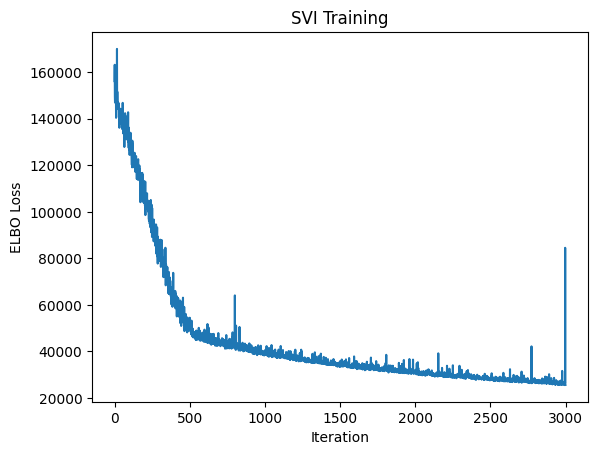

In [ ]:
guide = AutoDiagonalNormal(bayesian_flood_model)


pyro.clear_param_store()

#optimizer and SVI object
svi_optimizer = PyroAdam({"lr": 0.005})
svi = SVI(bayesian_flood_model, guide, svi_optimizer, loss=Trace_ELBO())

num_iterations = 3000
losses = []

for step in range(num_iterations):
    loss = svi.step(X_train_t, y_train_t)
    losses.append(loss)
    if step % 100 == 0:
        print(f"Iteration {step} | ELBO Loss: {loss:.2f}")

# ELBO loss curve
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("ELBO Loss")
plt.title("SVI Training")
plt.show()

In [ ]:
X_test_t = torch.tensor(X_test, dtype=torch.float)
y_test_t = torch.tensor(y_test.reshape(-1, 1), dtype=torch.float)

In [ ]:
predictive = Predictive(bayesian_flood_model, guide=guide, num_samples=1000, return_sites=("obs", "sigma"))
samples = predictive(X_test_t)

y_pred_samples = samples["obs"].detach().numpy()

#(uncertainty) across the samples
y_pred_mean = y_pred_samples.mean(axis=0)
y_pred_std = y_pred_samples.std(axis=0)
y_test_np = y_test_t.squeeze().detach().numpy()

# Calculate evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_np, y_pred_mean))
mae = mean_absolute_error(y_test_np, y_pred_mean)
r2 = r2_score(y_test_np, y_pred_mean)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE: {mae:.4f}")
print(f"Test R^2: {r2:.4f}")

Test RMSE: 0.3817
Test MAE: 0.1388
Test R^2: 0.4467


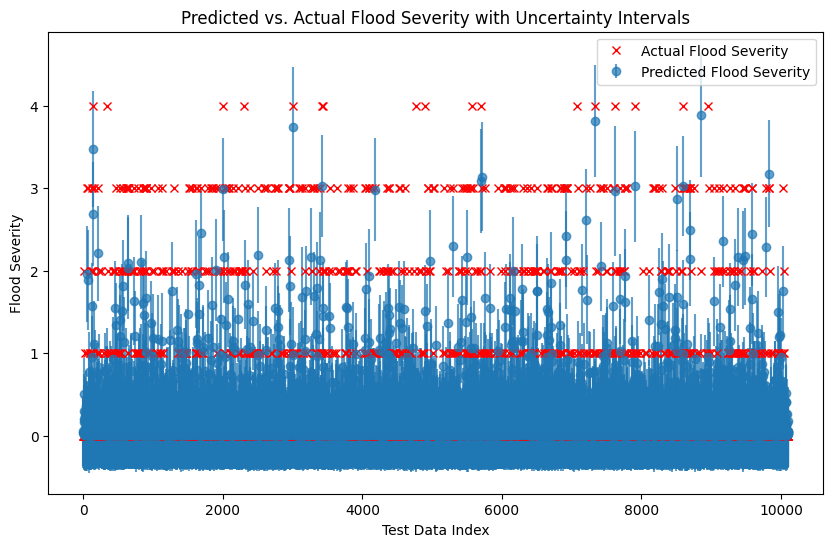

In [ ]:
plt.figure(figsize=(10,6))
plt.errorbar(range(len(y_test_np)), y_pred_mean, yerr=y_pred_std, fmt='o', alpha=0.7, label="Predicted Flood Severity")
plt.plot(y_test_np, 'rx', label="Actual Flood Severity")
plt.xlabel("Test Data Index")
plt.ylabel("Flood Severity")
plt.title("Predicted vs. Actual Flood Severity with Uncertainty Intervals")
plt.legend()
plt.show()

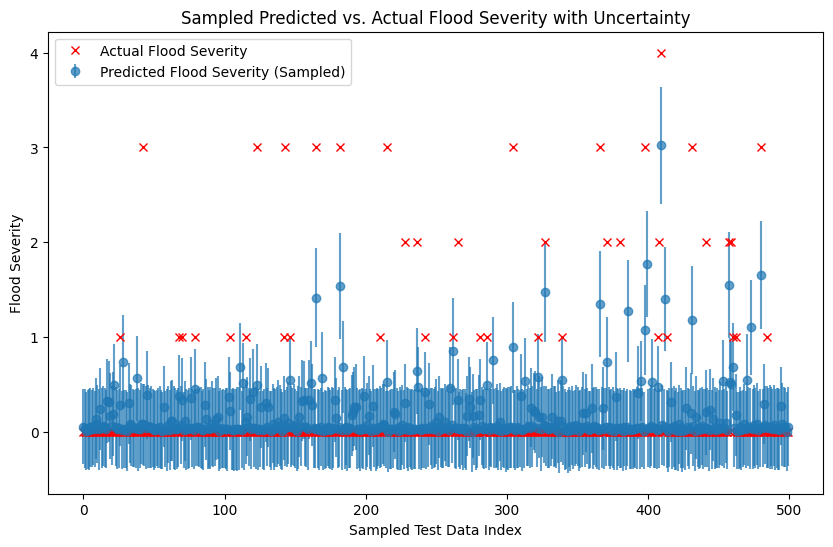

In [ ]:
sample_size = 500
all_indices = np.arange(len(y_test_np))
sample_indices = np.random.choice(all_indices, size=sample_size, replace=False)

sampled_y_test = y_test_np[sample_indices]
sampled_y_pred_mean = y_pred_mean[sample_indices]
sampled_y_pred_std = y_pred_std[sample_indices]

plt.figure(figsize=(10, 6))
plt.errorbar(
    x=range(sample_size),
    y=sampled_y_pred_mean,
    yerr=sampled_y_pred_std,
    fmt='o',
    alpha=0.7,
    label="Predicted Flood Severity (Sampled)"
)
plt.plot(sampled_y_test, 'rx', label="Actual Flood Severity")
plt.xlabel("Sampled Test Data Index")
plt.ylabel("Flood Severity")
plt.title("Sampled Predicted vs. Actual Flood Severity with Uncertainty")
plt.legend()
plt.show()